In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
column_names = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week","native_country","income"
]

df = pd.read_csv("/Users/yashi/Desktop/fairness_auditor_project/data/adult/adult.data",
                 names=column_names,
                 na_values=" ?",
                 skipinitialspace=True)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.shape

(32561, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [8]:
df = df.dropna()

df.shape

(32561, 15)

In [9]:
df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

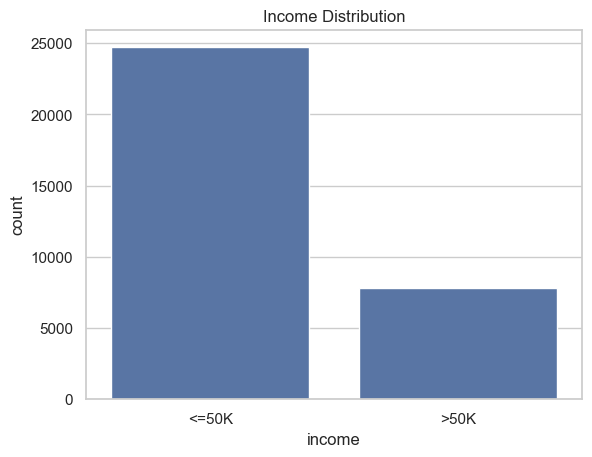

In [10]:
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()

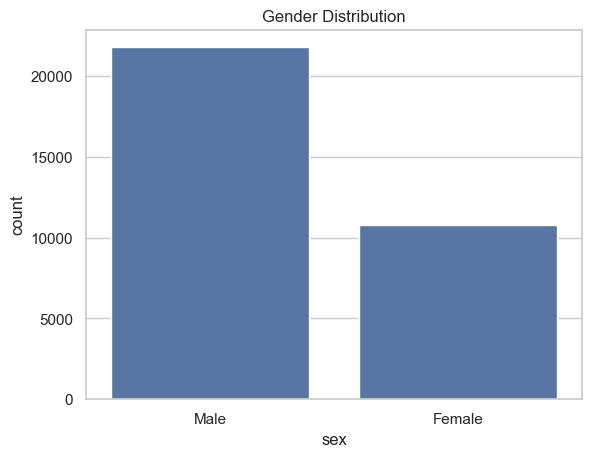

In [11]:
sns.countplot(x="sex", data=df)
plt.title("Gender Distribution")
plt.show()

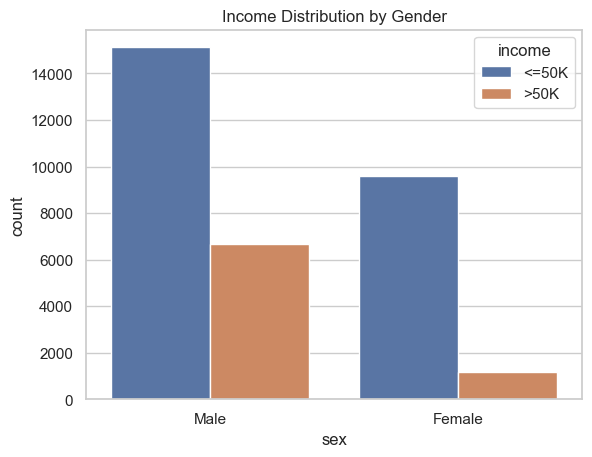

In [12]:
sns.countplot(x="sex", hue="income", data=df)
plt.title("Income Distribution by Gender")
plt.show()

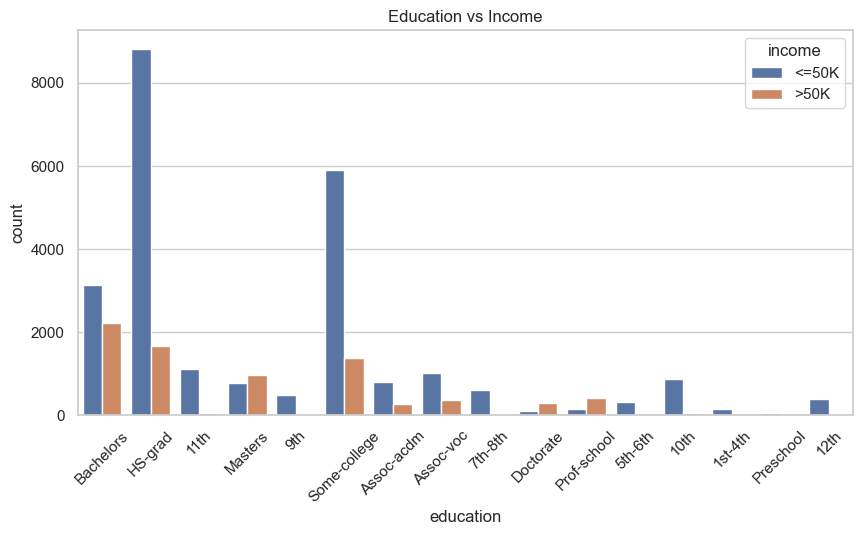

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(x="education", hue="income", data=df)

plt.xticks(rotation=45)
plt.title("Education vs Income")
plt.show()

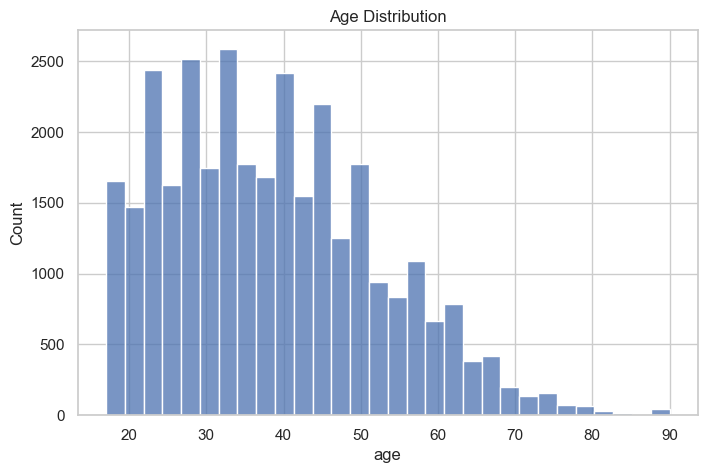

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")
plt.show()

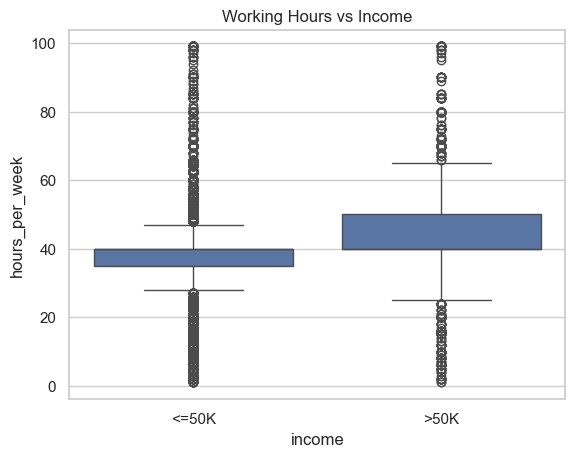

In [15]:
sns.boxplot(x="income", y="hours_per_week", data=df)

plt.title("Working Hours vs Income")
plt.show()

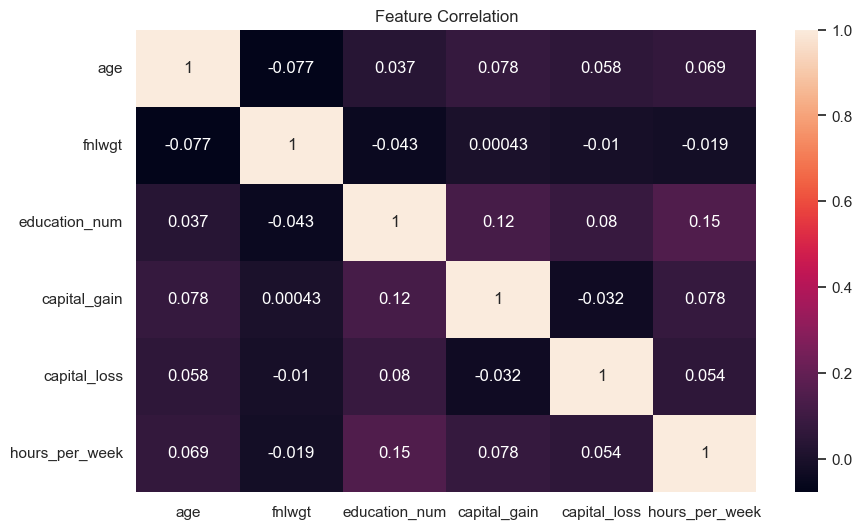

In [16]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric.corr(), annot=True)

plt.title("Feature Correlation")
plt.show()

In [17]:
group_rates = df.groupby("sex")["income"].value_counts(normalize=True)

group_rates

sex     income
Female  <=50K     0.890539
        >50K      0.109461
Male    <=50K     0.694263
        >50K      0.305737
Name: proportion, dtype: float64

In [18]:
positive_rate = df[df["income"] == ">50K"].groupby("sex").size() / df.groupby("sex").size()

positive_rate

sex
Female    0.109461
Male      0.305737
dtype: float64

In [19]:
print("Key Observations")

print("1. Dataset contains demographic and socioeconomic attributes.")
print("2. Income class is imbalanced.")
print("3. Male representation is higher than female.")
print("4. Higher education correlates with higher income.")
print("5. Differences in income distribution across gender indicate potential bias.")

Key Observations
1. Dataset contains demographic and socioeconomic attributes.
2. Income class is imbalanced.
3. Male representation is higher than female.
4. Higher education correlates with higher income.
5. Differences in income distribution across gender indicate potential bias.
